In [1]:
import sys
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import numpy as np
sys.path.append("/Users/gabriel/Desktop/Quant_Project/Quant-Summer-Project")
from scipy.stats import norm
from tests.fixtures.synthetic_data import synthetic_actual_df, synthetic_previous_df
from data import fetcher
from data.fetcher import (
fetch_data,
get_tommorows_wheather,
pair_dataframes,compute_forecast_error,
fetch_previous_forecast_data,
get_daily_max,
call_fetcher_functions,
)

from data.cleaner import clean_data
from data.loader import (
add_event_column,
filter_summer
)
from config.settings import (
HISTORICAL_START,
HISTORICAL_END,
DEFAULT_CITY,
TOMMORROWS_DATE,
FORECAST_START,
FORECAST_END 
)

#fetcher.fetch_data = lambda *args, **kwargs: synthetic_actual_df()
#fetcher.fetch_previous_forecast_data = lambda *args, **kwargs: synthetic_previous_df()
#fetcher.get_tommorows_wheather = lambda *args, **kwargs: 30

df_pair = call_fetcher_functions(FORECAST_START,FORECAST_END)

print(df_pair)
df_compute_error,mean_error,error = compute_forecast_error(df_pair)






shape: (1_858, 3)
┌────────────┬─────────────┬─────────────────────┐
│ date       ┆ actual_temp ┆ daily_max_predicted │
│ ---        ┆ ---         ┆ ---                 │
│ str        ┆ f64         ┆ f64                 │
╞════════════╪═════════════╪═════════════════════╡
│ 2021-05-08 ┆ 27.1        ┆ 28.6                │
│ 2021-05-09 ┆ 27.6        ┆ 28.8                │
│ 2021-05-10 ┆ 28.1        ┆ 29.0                │
│ 2021-05-11 ┆ 29.1        ┆ 29.7                │
│ 2021-05-12 ┆ 28.5        ┆ 30.3                │
│ …          ┆ …           ┆ …                   │
│ 2026-06-24 ┆ 31.5        ┆ 31.2                │
│ 2026-06-25 ┆ 31.5        ┆ 32.1                │
│ 2026-06-26 ┆ 29.8        ┆ 31.4                │
│ 2026-06-27 ┆ 29.6        ┆ 28.2                │
│ 2026-06-28 ┆ 28.7        ┆ 29.6                │
└────────────┴─────────────┴─────────────────────┘


We measured a mean forecast error of +0.38°C (expected ~0 for an unbiased forecast). This indicates the forecast has a systematic warm bias of about 0.38°C — predictions tend to run slightly hotter than what actually happens.
Rather than manually subtracting this bias every time a forecast value is used elsewhere in the code, we bake the correction into the likelihood mean itself (used in the Bayesian posterior update) — so any caller just gets an already-debiased estimate, with the correction applied in one place.

0.09217144422570134


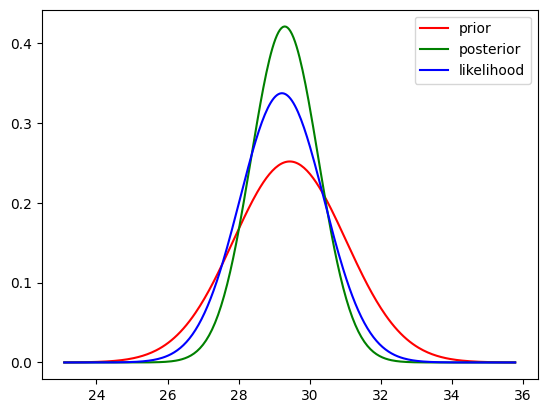

In [2]:
from models.bayesian_model import (
bayesian_interference,
posterior_probability,


)


df_raw = fetch_data(HISTORICAL_START,HISTORICAL_END)


df_clean = clean_data(df_raw)


df_event = add_event_column(df_clean)


df_temp_summer = filter_summer(df_event)

df_temp_list = df_temp_summer["temperature_2m_max"].to_list()

day = df_pair["date"].to_list()[-1]

sigma_posterior, sigma_prior,sigma_forecast, my_posterior,my_prior,likelihood_mean = bayesian_interference(df_temp_list,day,df_pair)

P =  posterior_probability(df_temp_list,day,df_pair,30.5,31.5)
print(P)

df_sorted = sorted(df_temp_list)
sigma_posterior, sigma_prior,sigma_forecast, my_posterior,my_prior,likelihood_mean = bayesian_interference(df_sorted,day,df_pair)
x_min = min(my_prior - 4*sigma_prior, likelihood_mean - 4*sigma_forecast, my_posterior - 4*sigma_posterior)
x_max = max(my_prior + 4*sigma_prior, likelihood_mean + 4*sigma_forecast, my_posterior + 4*sigma_posterior)
x = np.linspace(x_min, x_max, 300)

df_norm1 = norm.pdf(x,my_prior,sigma_prior)
df_norm2 = norm.pdf(x,my_posterior,sigma_posterior)
df_norm3 = norm.pdf(x,likelihood_mean,sigma_forecast)
plt.plot(x,df_norm1,color = 'r', label ='prior')
plt.plot(x,df_norm2,color = 'g',label = 'posterior')
plt.plot(x,df_norm3,color = 'b',label = 'likelihood')

plt.legend()


Alright so we can see that the posterior is tallest, second is likelihood and last is prior. Posterior center around 29, likelihood a bit less then that like 28.5 and prior at 29.5 approximatly. Prior has more of a wider shape and more distance between maxima. Where posterior has the smalles and most narrowsest peak.